In [ ]:
import torch
import torchvision
from torchvision import transforms as T
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load pretrained Mask R-CNN
def load_model():
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
    model.eval()
    return model

def predict(model, image_path, threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image)

    with torch.no_grad():
        predictions = model([image_tensor])

    return image, predictions[0]

def visualize(image, prediction, threshold=0.5):
    image_np = np.array(image).copy()

    boxes = prediction["boxes"]
    scores = prediction["scores"]
    masks = prediction["masks"]

    for i in range(len(scores)):
        if scores[i] > threshold:
            box = boxes[i].int().numpy()
            mask = masks[i, 0].numpy()

            # Draw bounding box
            cv2.rectangle(
                image_np,
                (box[0], box[1]),
                (box[2], box[3]),
                (0, 255, 0),
                2,
            )

            # Apply mask
            mask_binary = mask > 0.5
            image_np[mask_binary] = image_np[mask_binary] * 0.5 + np.array([255, 0, 0]) * 0.5

    return image_np.astype(np.uint8)

if __name__ == "__main__":
    model = load_model()

    input_image = "test.jpg"
    image, prediction = predict(model, input_image)

    result = visualize(image, prediction, threshold=0.6)

    cv2.imwrite("output.jpg", cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
    print("Saved output to output.jpg")


Saved output to output.jpg


Using cache found in C:\Users\ASUS/.cache\torch\hub\intel-isl_MiDaS_master
c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


Using cache found in C:\Users\ASUS/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\ASUS/.cache\torch\hub\intel-isl_MiDaS_master


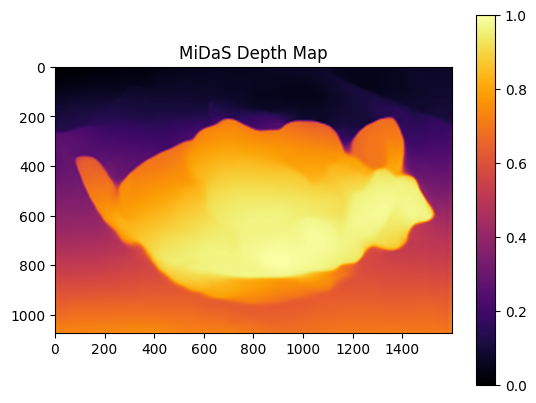

In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load MiDaS model
model_type = "MiDaS_small"  # options: DPT_Large, DPT_Hybrid, MiDaS_small
midas = torch.hub.load("intel-isl/MiDaS", model_type)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)
midas.eval()

# Load transforms
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type in ["DPT_Large", "DPT_Hybrid"]:
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

# Load image
img = cv2.imread("images4.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

# Predict depth
with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth_map = prediction.cpu().numpy()

# Normalize for visualization
depth_map_norm = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())

plt.imshow(depth_map_norm, cmap='inferno')
plt.colorbar()
plt.title("MiDaS Depth Map")
plt.show()


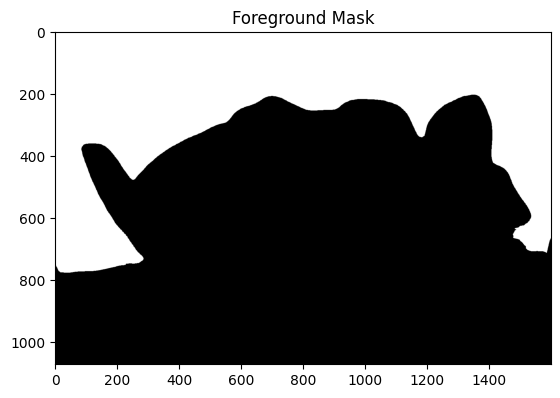

In [4]:
# Simple foreground mask
threshold = 0.5  # tune this
mask = depth_map_norm < threshold  # smaller = closer in MiDaS

plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.show()

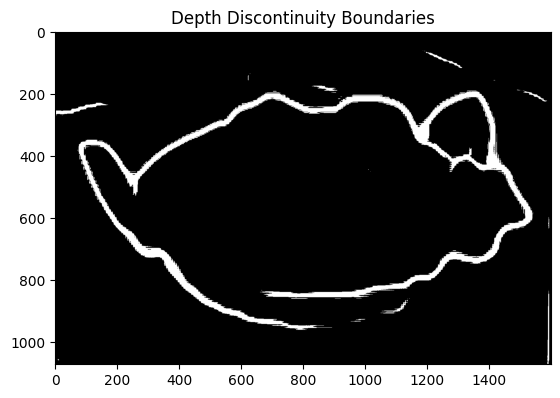

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ensure depth is float32
depth = depth_map_norm.astype(np.float32)

# Compute gradients
grad_x = cv2.Sobel(depth, cv2.CV_32F, 1, 0, ksize=3)
grad_y = cv2.Sobel(depth, cv2.CV_32F, 0, 1, ksize=3)

# Gradient magnitude
grad_mag = np.sqrt(grad_x**2 + grad_y**2)

# Normalize for visualization
grad_mag_norm = (grad_mag - grad_mag.min()) / (grad_mag.max() - grad_mag.min())

# Threshold on depth discontinuity
edge_threshold = 0.05   # tune this
edges = grad_mag_norm > edge_threshold

plt.imshow(edges, cmap='gray')
plt.title("Depth Discontinuity Boundaries")
plt.show()

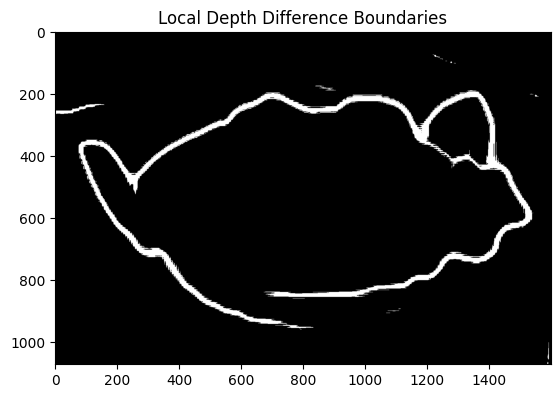

In [4]:
depth = depth_map_norm.astype(np.float32)

# Horizontal and vertical differences
diff_x = np.abs(depth[:, 1:] - depth[:, :-1])
diff_y = np.abs(depth[1:, :] - depth[:-1, :])

# Pad to original size
diff_x = np.pad(diff_x, ((0,0),(0,1)), mode='constant')
diff_y = np.pad(diff_y, ((0,1),(0,0)), mode='constant')

# Combine
diff = np.maximum(diff_x, diff_y)

# Threshold
boundary_threshold = 0.005  # tune
boundaries = diff > boundary_threshold

plt.imshow(boundaries, cmap='gray')
plt.title("Local Depth Difference Boundaries")
plt.show()

In [ ]:
import numpy as np
import cv2

h, w = 480, 640

fx = 600
fy = 600
cx = w // 2
cy = h // 2

Z_near = 0.3
Z_far = 1.5

u, v = np.meshgrid(np.arange(w), np.arange(h))

sphere_radius = 0.15  
sphere_center_z = 0.8
X = (u - cx) * sphere_center_z / fx
Y = (v - cy) * sphere_center_z / fy

inside_sphere = X**2 + Y**2 <= sphere_radius**2

depth_metric = np.ones((h, w)) * 1.2  
depth_metric[inside_sphere] = sphere_center_z - np.sqrt(
    sphere_radius**2 - (X[inside_sphere]**2 + Y[inside_sphere]**2)
)

depth_map_norm = (depth_metric - Z_near) / (Z_far - Z_near)

mask = inside_sphere

In [13]:
depth = Z_near + depth_map_norm * (Z_far - Z_near)

In [14]:
def compute_volume_surface_integration(depth, mask, fx, fy):
    Z = depth[mask]
    volume = np.sum((Z**3) / (fx * fy))
    return volume

vol1 = compute_volume_surface_integration(depth, mask, fx, fy)
print("Method 1 Volume:", vol1, "m^3")

Method 1 Volume: 0.03818142029476226 m^3


In [8]:
import open3d as o3d

def compute_volume_mesh(depth, mask, fx, fy, cx, cy):

    h, w = depth.shape
    points = []

    for v in range(h):
        for u in range(w):
            if mask[v, u]:
                Z = depth[v, u]
                X = (u - cx) * Z / fx
                Y = (v - cy) * Z / fy
                points.append([X, Y, Z])

    points = np.array(points)

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    pcd.estimate_normals()

    mesh, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd, depth=8
    )

    bbox = pcd.get_axis_aligned_bounding_box()
    mesh = mesh.crop(bbox)

    volume = mesh.get_volume()
    return volume

vol2 = compute_volume_mesh(depth, mask, fx, fy, cx, cy)
print("Method 2 Volume:", vol2, "m^3")

ModuleNotFoundError: No module named 'open3d'